# this is a mini MVA project 

In [2]:
import pandas as pd 
import numpy as np
import pingouin as pg
import plotly.express as px
import matplotlib.pyplot as plt  
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv('/mnt/78AA22ECAA22A71A/K_REPO/project555/data/HATCO_clean.csv')
df.head()

,id,delivery_speed,price_level,price_flexibility,manufacturer_image,service_level,salesforce_image,product_quality,firm_size,usage_level,satisfaction,spec_buying,procurement_structure,industry_type,buying_situation
0,1,4.1,0.6,6.9,4.7,2.4,2.3,5.2,0,32,4.2,1,0,1,1
1,2,1.8,3.0,6.3,6.6,2.5,4.0,8.4,1,43,4.3,0,1,0,1
2,3,3.4,5.2,5.7,6.0,4.3,2.7,8.2,1,48,5.2,0,1,1,2
3,4,2.7,1.0,7.1,5.9,1.8,2.3,7.8,0,32,3.9,0,1,1,1
4,5,6.0,0.9,9.6,7.8,3.4,4.6,4.5,2,58,6.8,1,0,1,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     100 non-null    int64  
 1   delivery_speed         100 non-null    float64
 2   price_level            100 non-null    float64
 3   price_flexibility      100 non-null    float64
 4   manufacturer_image     100 non-null    float64
 5   service_level          100 non-null    float64
 6   salesforce_image       100 non-null    float64
 7   product_quality        100 non-null    float64
 8   firm_size              100 non-null    int64  
 9   usage_level            100 non-null    int64  
 10  satisfaction           100 non-null    float64
 11  spec_buying            100 non-null    int64  
 12  procurement_structure  100 non-null    int64  
 13  industry_type          100 non-null    int64  
 14  buying_situation       100 non-null    int64  
dtypes: floa

## report the raw data stats

In [5]:
from ydata_profiling import ProfileReport

#profile = ProfileReport(df, title="Profiling Report")
#profile.to_file("your_report.html")

/home/killd00zer/miniconda3/envs/Yd312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### data is clean and ready for the tests

## 1st question: is the client scale affect the satisfaction level?

### 📌 RQ1: Firm Size vs. Satisfaction

**Question:** Does average satisfaction (`X10`) differ significantly by firm size (`X8`)?

**Test:** One-Way ANOVA

**Variables:**
* **IV:** `X8` (Firm Size) [0 = Small, 1 = Medium, 2 = Large]
* **DV:** `X10` (Satisfaction Level) [Scale: 0–10]

**Hypotheses:**
* **$H_0$:** $\mu_{small} = \mu_{medium} = \mu_{large}$ (No difference)
* **$H_1$:** At least one mean differs (Difference exists)

**Steps:**
1. **Normality:** Shapiro-Wilk Test.
2. **Homogeneity of Variance:** Levene's Test.
3. **Execution:** Run One-Way ANOVA and evaluate the *P-value*.

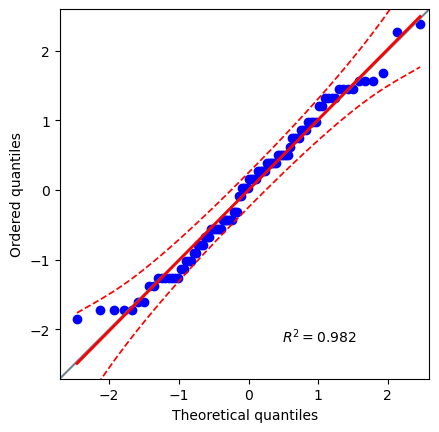

                    W      pval  normal
satisfaction  0.97675  0.073995    True
                                     ✅


In [6]:
# test normalty of DV  H0: in normal.dist
%matplotlib inline
ax = pg.qqplot(df["satisfaction"], dist='norm')
plt.show()
print(pg.normality(df["satisfaction"]  ))
print("                                     ✅")   #H0: DV is in N.Dist                                 # Univariate normality

In [7]:
# homogeneity test, H0: DV is homogenies (levenes test)
print(pg.homoscedasticity(data=df, dv='satisfaction', group='firm_size'))
print("                                  ✅")   #H0: DV is in N.Dist                                 # Univariate normality

               W      pval  equal_var
levene  1.290779  0.279738       True
                                  ✅


#### Anova test, **$H_0$:** $\mu_{0} = \mu_{1} = \mu_{2}$ (No difference)

In [8]:
#H0: mean satisfaction is equal across Small, Medium, and Large firms
pg.anova(data=df, dv="satisfaction" ,between='firm_size', detailed=False)

,Source,ddof1,ddof2,F,p_unc,np2
0,firm_size,2,97,39.543317,2.758666e-13,0.449135


In [9]:
print(df.groupby('firm_size')['satisfaction'].mean())

firm_size
0    3.996667
1    4.815789
2    5.443750
Name: satisfaction, dtype: float64


### 📊 One-Way ANOVA Result

- F = 39.54 is very large → there is a strong group effect
- p < 0.001 → the difference is **statistically significant** at α = 0.05
- np² = 0.449 → **large effect size** (firm size explains ~45% of satisfaction variance)

**Conclusion:**
<span style="color:red">At least one firm-size group has a significantly **different mean of satisfaction** compared to the others. (Small / Medium / Large firms perceive satisfaction differently.)</span>


### *************************************************************************

## 2nd question: Does the client scale(firm size) affect multiple performance metrics simultaneously?

### 📌 RQ2: Firm Size vs. Performance Perceptions

**Question:** Do the average performance perceptions (e.g., `X1` Delivery Speed, `X2` Service Level, `X3` Product Quality) differ significantly based on firm size (`X8`)?

**Test:** One-Way MANOVA (Multivariate Analysis of Variance)

**Variables:**
* **IV:** `X8` (Firm Size) [Categorical: 0 = Small, 1 = Medium, 2 = Large]
* **DVs:** `X1` (Delivery Speed), `X2` (Service Level), `X3` (Product Quality) [Continuous Scale: 0–10]

**Hypotheses:**
* **$H_0$:** $\boldsymbol{\mu}_{small} = \boldsymbol{\mu}_{medium} = \boldsymbol{\mu}_{large}$ (No difference in the *mean vectors* across groups)
* **$H_1$:** At least one group mean vector differs (firm size affects at least one of the perceptions)

**Steps:**
1. **Multivariate Normality:** Shapiro-Wilk for each DV.
2. **Homogeneity of Covariance Matrices:** Box's M Test (the MANOVA equivalent of Levene's test — compares a *matrix* of multiple DVs across groups).
3. **Homoscedasticity:** Levene's Test (for each DV individually).
4. **Execution:** Run MANOVA and evaluate the *P-value* using **Pillai's Trace** (most robust with 3 groups and heteroscedasticity).

### test normality 

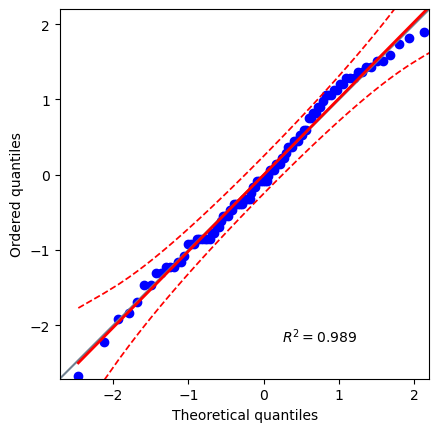

                       W      pval  normal
delivery_speed  0.985425  0.340633    True


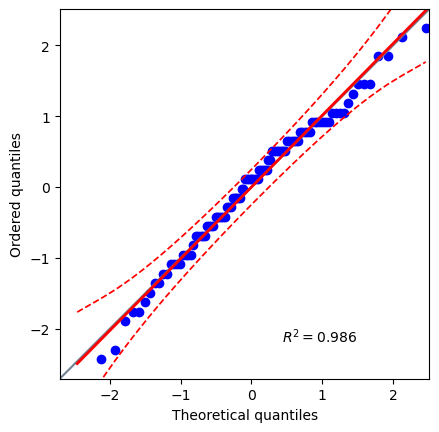

                      W      pval  normal
service_level  0.985861  0.365702    True


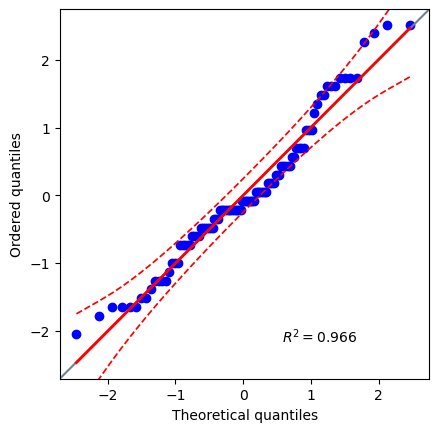

                         W      pval  normal
salesforce_image  0.963413  0.007094   False


In [10]:
# test multi normality 
Iv= df["firm_size"]
Dvs= ["delivery_speed","service_level","salesforce_image"]

%matplotlib inline

for i in Dvs :
    ax = pg.qqplot(df[i], dist='norm')
    plt.show()
    print(pg.normality(df[i]))   #H0: DV is in N.Dist                                 # Univariate normality

#### only salesforce_image was so close but failed the normalty, will fix it by BOXCOX

Optimal Box-Cox Lambda: 0.3979



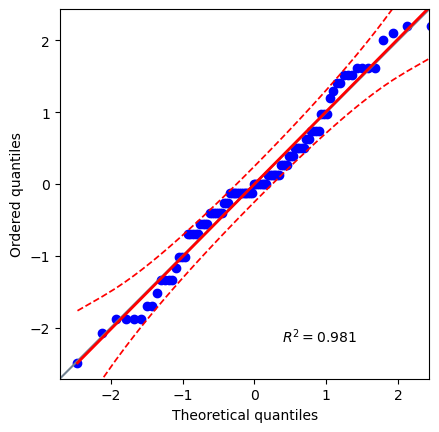

                            W      pval  normal
salesforce_image_bc  0.978127  0.094898    True


In [11]:
from scipy.stats import boxcox
df['salesforce_image_bc'], best_lambda = boxcox(df['salesforce_image'])
print(f"Optimal Box-Cox Lambda: {best_lambda:.4f}\n")

ax = pg.qqplot(df["salesforce_image_bc"], dist='norm')
plt.show()
print(pg.normality(df["salesforce_image_bc"],)) 

In [12]:
# Tests if salesforce_image is normal for small firms AND normal for large firms
pg.normality(data=df, dv='salesforce_image_bc', group='firm_size')


,W,pval,normal
firm_size,,,
0,0.944671,0.121546,True
1,0.963112,0.239296,True
2,0.970093,0.501960,True


### 📊 Normality Assessment

**The Problem:** When testing `salesforce_image` across the full sample, it narrowly failed the Shapiro-Wilk normality test ($p = 0.007 < 0.05$), meaning we reject the hypothesis that the data is perfectly normally distributed.

**Box-Cox Exploration:** We applied a **Box-Cox transformation** ($\lambda = 0.39$) to push the distribution closer to a bell curve. The transformed variable improved to $p = 0.094$, which still technically fails at $\alpha = 0.05$ — so the overall normality issue is not fully resolved by transformation alone.

**What Actually Matters for MANOVA — Within-Group Normality:**
MANOVA requires normality *within each group*, not across the full sample. More importantly, when we split the data by `firm_size` (which is what MANOVA cares about), **all three groups (Small, Medium, and Large)** passed the normality test perfectly ($p > 0.05$). This satisfies the MANOVA assumption of multivariate normality within each group, and we can proceed.


### test Homogeneity of Covariance Matrices

In [13]:
box_m_result = pg.box_m(data=df, dvs=["delivery_speed", "service_level", "salesforce_image"], group='firm_size')
print(box_m_result)

          Chi2    df      pval  equal_cov
box  20.639284  12.0  0.055919       True


#### the covariance of DVs in large firms & small firms are equal can go for manova instead of mancova

### test the homoscedastisty of each DV alone

In [14]:
Dvs_with_bc= ["delivery_speed","service_level","salesforce_image_bc"]

for i in Dvs_with_bc:
    print(f"{i} homoscedasticity result: \n {pg.homoscedasticity(data=df, dv=i, group='firm_size')} \n\n")

delivery_speed homoscedasticity result: 
                W      pval  equal_var
levene  0.524187  0.593704       True 


service_level homoscedasticity result: 
                W      pval  equal_var
levene  2.643644  0.076222       True 


salesforce_image_bc homoscedasticity result: 
                W      pval  equal_var
levene  1.841199  0.164128       True 




#### this means only delivary speed is homosced between large and small firms , others are hetro (no is the same range of variance)

In [15]:
print(df['firm_size'].value_counts())

firm_size
1    38
2    32
0    30
Name: count, dtype: int64


#### so its Pillai's trace Manova will be robust aganist the non-normality and hetroscedasticity .. in statsmodels

### run the manova test

In [16]:
from statsmodels.multivariate.manova import MANOVA
from IPython.display import display

In [17]:
manova = MANOVA.from_formula('delivery_speed + service_level + salesforce_image ~ C(firm_size)', data=df)
results = manova.mv_test()
print(results)

                  Multivariate linear model
                                                             
-------------------------------------------------------------
       Intercept        Value  Num DF  Den DF F Value  Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.1210 3.0000 95.0000 230.1272 0.0000
         Pillai's trace 0.8790 3.0000 95.0000 230.1272 0.0000
 Hotelling-Lawley trace 7.2672 3.0000 95.0000 230.1272 0.0000
    Roy's greatest root 7.2672 3.0000 95.0000 230.1272 0.0000
-------------------------------------------------------------
                                                             
-------------------------------------------------------------
      C(firm_size)      Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.4817 6.0000 190.0000 13.9596 0.0000
         Pillai's trace 0.5608 6.0000 192.0000 12.4681 0.0000
 Hotelling-Lawley trace 0.

### 💡 Analytical Note: Interpreting MANOVA Test Statistics

**Observation:** In the `C(firm_size)` results above, all four multivariate test statistics (Wilks' Lambda, Pillai's Trace, Hotelling-Lawley, Roy's Greatest Root) consistently indicate a highly significant result ($p < 0.001$). 

**Why are the F-values different?**
Unlike scenarios where an independent variable has exactly two groups (which causes all four test statistics to converge mathematically), the $F$-values here vary (e.g., Wilks' $\Lambda$ $F = 13.96$ vs. Pillai's Trace $F = 12.47$). This divergence, along with the numerator degrees of freedom (`Num DF` = 6), confirms that the independent variable (`firm_size`) consists of **three or more groups** (e.g., Small, Medium, Large). 

**🎯 Final Conclusion (RQ2):** 
We reject the null hypothesis ($H_0$). There is a highly significant multivariate effect of firm size on the combined performance perceptions (Wilks' $\Lambda = 0.482$, $F(6, 190) = 13.96$, $p < 0.001$). Firms of different sizes perceive HATCO's overall performance fundamentally differently.